# Data Collection and Data Preprocessing

## Importing the libraries

In [ ]:
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg
import pandas as pd

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


## Fetching the dataset

In [ ]:
data = gutenberg.raw('shakespeare-hamlet.txt')
with open('hamlet.txt', 'w') as file:
    file.write(data)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

## Converting the dataset into lower and save it

In [ ]:
with open('hamlet.txt', 'r') as file:
    text = file.read().lower()

## Converting into tokens

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index)+1
total_words

4818

In [ ]:
# tokenizer.word_index


## Creating the input sequence

In [ ]:
input_sequences=[]
for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

In [ ]:
# input_sequences

## Pad Sequencing

In [ ]:
max_sequence_len = max([len(x) for x in input_sequences])
max_sequence_len

14

In [ ]:
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
input_sequences

array([[   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       [   0,    0,    0, ...,  687,    4,   45],
       ...,
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4],
       [   0,    0,    0, ..., 1047,    4,  193]], dtype=int32)

## Creating prediction and labels

In [ ]:
import tensorflow as tf

x, y = input_sequences[:, : -1], input_sequences[:, -1]

In [ ]:
y

array([ 687,    4,   45, ..., 1047,    4,  193], dtype=int32)

In [ ]:
x

array([[   0,    0,    0, ...,    0,    0,    1],
       [   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       ...,
       [   0,    0,    0, ...,  687,    4,   45],
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4]], dtype=int32)

In [ ]:
y = tf.keras.utils.to_categorical(y, num_classes=total_words)
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Split the data into training and testing

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# LSTM Neural Network Model Training

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, GRU

## Define the Model (LSTM)

In [ ]:
model = Sequential()
model.add(Input(shape=(max_sequence_len-1,)))
model.add(Embedding(total_words, 100))
model.add(LSTM(150, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dense(total_words, activation='softmax'))

## Compile the model

In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 100)        │       481,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 13, 150)        │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4818)           │       486,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,219,418 (4.65 MB)

 Trainable params: 1,219,418 (4.65 MB)

 Non-trainable params: 0 (0.00 B)

## Train the model

In [ ]:
history = model.fit(x_train, y_train, epochs=100, validation_data=(x_test, y_test), verbose=1)

Epoch 1/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.0320 - loss: 6.9083 - val_accuracy: 0.0336 - val_loss: 6.6909
Epoch 2/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.0386 - loss: 6.4709 - val_accuracy: 0.0408 - val_loss: 6.7567
Epoch 3/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.0471 - loss: 6.3255 - val_accuracy: 0.0476 - val_loss: 6.7758
Epoch 4/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.0523 - loss: 6.1888 - val_accuracy: 0.0525 - val_loss: 6.8259
Epoch 5/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.0558 - loss: 6.0658 - val_accuracy: 0.0550 - val_loss: 6.8504
Epoch 6/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.0585 - loss: 5.9358 - val_accuracy: 0.0610 - val_loss: 6.9131
Epoch 7/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.0669 - loss: 5.8031 - val_accuracy: 0.0622 - val_loss: 6.9614
Epoch 8/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0708 - loss: 5.6717 -

## Function to predict the next word with LSTM model

In [ ]:
def predict_next_word(seed_text, model, tokenizer, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    if len(token_list)>=max_sequence_len:
        token_list = token_list[-(max_sequence_len-1):]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

In [ ]:
input_text = 'to be or not to be'

In [ ]:
print(f"input text: {input_text}")
max_sequence_len = model.input_shape[1]+1
next_word = predict_next_word(input_text, model, tokenizer, max_sequence_len)
print(f"Next Predicted Word is: {next_word}")

input text: to be or not to be
Next Predicted Word is: made


## Save the model

In [33]:
model.save('LSTM_model.h5')

import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [39]:
input_text = "Mar. haratio saies, 'tis but our"
print(f"input text: {input_text}")
max_sequence_len = model.input_shape[1]+1
next_word = predict_next_word(input_text, model, tokenizer, max_sequence_len)
print(f"Next Predicted Word is: {next_word}")

input text: Mar. haratio saies, 'tis but our
Next Predicted Word is: fantasie


## Define the model (GRU)

In [41]:
model1 = Sequential()
model1.add(Input(shape=(max_sequence_len-1,)))
model1.add(Embedding(total_words, 100))
model1.add(GRU(150, return_sequences=True))
model1.add(Dropout(0.2))
model1.add(GRU(100))
model1.add(Dense(total_words, activation='softmax'))

In [42]:
model1.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 100)        │       481,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 13, 150)        │       113,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100)            │        75,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4818)           │       486,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,157,418 (4.42 MB)

 Trainable params: 1,157,418 (4.42 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history1 = model1.fit(x_train, y_train, epochs=100, validation_data=(x_test, y_test), verbose=1)

Epoch 1/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.0487 - loss: 6.4162 - val_accuracy: 0.0563 - val_loss: 6.6728
Epoch 2/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.0617 - loss: 6.1308 - val_accuracy: 0.0663 - val_loss: 6.6315
Epoch 3/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0769 - loss: 5.8338 - val_accuracy: 0.0727 - val_loss: 6.7082
Epoch 4/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.0858 - loss: 5.5442 - val_accuracy: 0.0734 - val_loss: 6.7933
Epoch 5/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.0977 - loss: 5.2615 - val_accuracy: 0.0734 - val_loss: 6.9202
Epoch 6/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1105 - loss: 4.9936 - val_accuracy: 0.0699 - val_loss: 7.0152
Epoch 7/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1278 - loss: 4.7393 - val_accuracy: 0.0668 - val_loss: 7.1094
Epoch 8/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1480 - loss: 4.5053 - v

## Function to predict the next word with LSTM model

In [45]:
def predict_next_word_GRU(seed_text, model1, tokenizer, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    if len(token_list)>=max_sequence_len:
        token_list = token_list[-(max_sequence_len-1):]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model1.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

In [47]:
input_text = 'to be or not to be'
print(f"input text: {input_text}")
max_sequence_len = model.input_shape[1]+1
next_word = predict_next_word_GRU(input_text, model, tokenizer, max_sequence_len)
print(f"Next Predicted Word is: {next_word}")

input text: to be or not to be
Next Predicted Word is: made


In [48]:
model.save('GRU_model.h5')

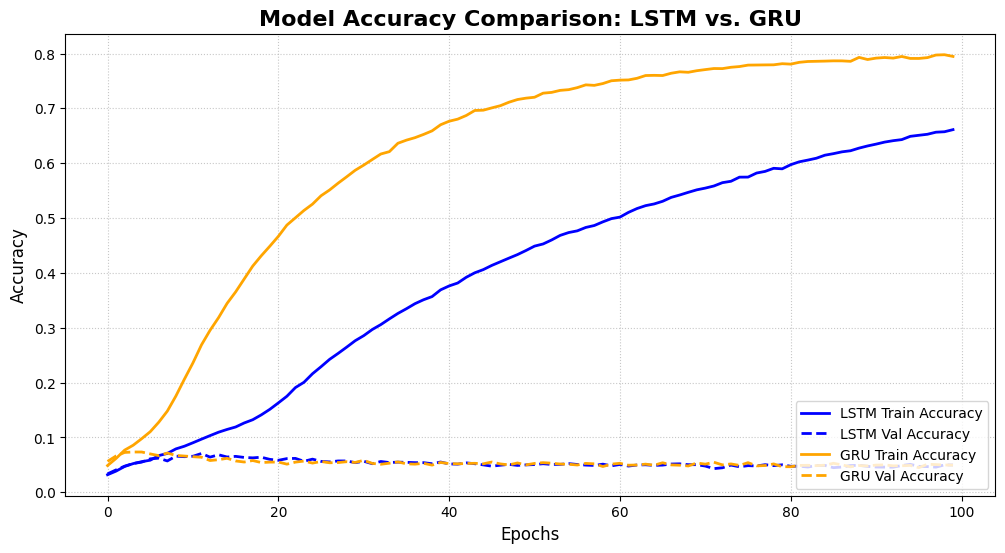

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# --- LSTM Accuracy ---

plt.plot(history.history['accuracy'], label='LSTM Train Accuracy', color='blue', linestyle='-', linewidth=2)

plt.plot(history.history['val_accuracy'], label='LSTM Val Accuracy', color='blue', linestyle='--', linewidth=2)

# --- GRU Accuracy ---


plt.plot(history1.history['accuracy'], label='GRU Train Accuracy', color='orange', linestyle='-', linewidth=2)


plt.plot(history1.history['val_accuracy'], label='GRU Val Accuracy', color='orange', linestyle='--', linewidth=2)

plt.title('Model Accuracy Comparison: LSTM vs. GRU', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()